# FBCL Model

Using device: cuda
Upload your 3 CSV files:
1. preprocessed_augmented_dataset_scaled.csv
2. validation_set_scaled.csv
3. test_set_scaled.csv


Saving test_set_scaled.csv to test_set_scaled (1).csv
Saving validation_set_scaled.csv to validation_set_scaled (1).csv
Saving preprocessed_augmented_dataset_scaled.csv to preprocessed_augmented_dataset_scaled (1).csv
Training file:   preprocessed_augmented_dataset_scaled (1).csv
Validation file: validation_set_scaled (1).csv
Test file:       test_set_scaled (1).csv
Number of features: 19 | Number of classes: 10

Training Severity_007 (Task 1/3)


/tmp/ipykernel_626/3293556732.py:194: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=cfg["n_layers"])


Severity_007 Ep 1/2:   0%|          | 0/391 [00:00<?, ?it/s]

Severity_007 Ep 2/2:   0%|          | 0/391 [00:00<?, ?it/s]

...

Severity_014 Ep 2/2:   0%|          | 0/391 [00:00<?, ?it/s]


Training Severity_021 (Task 3/3)


Severity_021 Ep 1/2:   0%|          | 0/391 [00:00<?, ?it/s]

Severity_021 Ep 2/2:   0%|          | 0/391 [00:00<?, ?it/s]


FINAL FBCL PERFORMANCE
Accuracy:  0.9485 (94.85%)
Precision: 0.9482
Recall:    0.9485
F1 Score:  0.9478


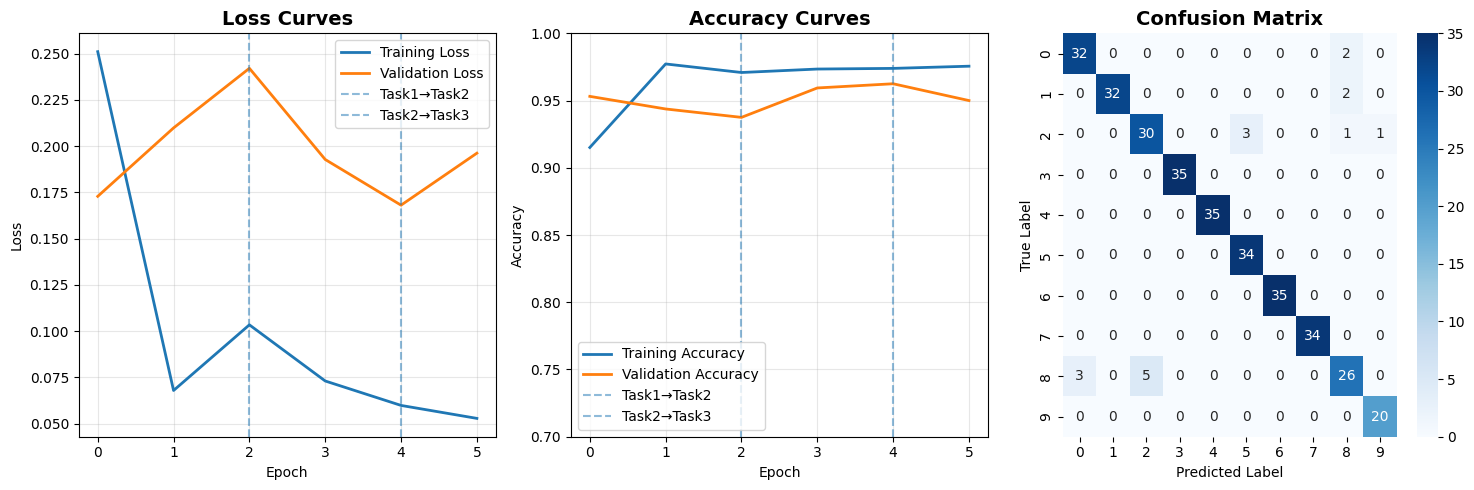


Final model saved to: /content/fbcl_final_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# FINAL FBCL (FEATURE BOOSTING CONTINUAL LEARNING) MODEL
# Optimized via ablation: boosting heads removed (best F1: 0.9485)

# !pip -q install torch torchvision torchaudio pandas numpy scikit-learn tqdm matplotlib

import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm
from google.colab import files

# ============================================================
# 1. Configuration (Optimal from ablation)
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

SEED = 42
set_seed(SEED)

# Dataset and task settings
TARGET_COL = "fault_encoded"
TASK_NAMES = ['Severity_007', 'Severity_014', 'Severity_021']
BATCH_SIZE = 256
EPOCHS_PER_TASK = 2        # adjust
PATIENCE = 25                # original patience
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Optimal configuration (based on ablation)
CONFIG = {
    "name": "final_optimal",
    "d_model": 256,
    "n_heads": 16,
    "n_layers": 6,
    "dropout": 0.15,
    "boosting_dropout": 0.12,
    "use_boosting_heads": False,      # REMOVED per ablation (+0.29% F1)
    "use_distillation": True,
    "use_batchnorm": True,
    "use_dropout": True,
    "use_weighted_sampler": True,
    "use_grad_clip": True,
    "use_lr_schedule": True,
    "lr": 3e-4,
    "weight_decay": 5e-5,
    "temperature": 2.5,
    "distillation_alpha": 0.8,
}

# ============================================================
# 2. Upload Data (Colab)
# ============================================================
print("Upload your 3 CSV files:")
print("1. preprocessed_augmented_dataset_scaled.csv")
print("2. validation_set_scaled.csv")
print("3. test_set_scaled.csv")
uploaded = files.upload()
uploaded_names = list(uploaded.keys())

def choose_file(kind):
    lower_names = [name.lower() for name in uploaded_names]
    if kind == "train":
        keywords = ["augmented", "train", "training", "preprocessed"]
    elif kind == "val":
        keywords = ["validation", "val"]
    elif kind == "test":
        keywords = ["test"]
    else:
        keywords = []
    candidates = [orig for orig, low in zip(uploaded_names, lower_names) if any(k in low for k in keywords)]
    if len(candidates) == 1:
        return candidates[0]
    print(f"Could not automatically choose the {kind} file. Available: {uploaded_names}")
    idx = int(input(f"Enter the index of the {kind} file: "))
    return uploaded_names[idx]

train_file = choose_file("train")
val_file   = choose_file("val")
test_file  = choose_file("test")
print("Training file:  ", train_file)
print("Validation file:", val_file)
print("Test file:      ", test_file)

train_df = pd.read_csv(train_file)
val_df   = pd.read_csv(val_file)
test_df  = pd.read_csv(test_file)

if TARGET_COL not in train_df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found. Columns: {list(train_df.columns)}")

feature_cols = [c for c in train_df.columns if c != TARGET_COL]
for df in [train_df, val_df, test_df]:
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df[feature_cols] = df[feature_cols].fillna(0)

label_encoder = LabelEncoder()
all_labels = pd.concat([train_df[TARGET_COL], val_df[TARGET_COL], test_df[TARGET_COL]], axis=0)
label_encoder.fit(all_labels)

X_train = train_df[feature_cols].values.astype(np.float32)
y_train = label_encoder.transform(train_df[TARGET_COL])
X_val   = val_df[feature_cols].values.astype(np.float32)
y_val   = label_encoder.transform(val_df[TARGET_COL])
X_test  = test_df[feature_cols].values.astype(np.float32)
y_test  = label_encoder.transform(test_df[TARGET_COL])

n_features = X_train.shape[1]
n_classes = len(label_encoder.classes_)
print("Number of features:", n_features, "| Number of classes:", n_classes)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_scaled,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

class_weights_np = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sample_weights = class_weights_np[y_train]
sample_weights_t = torch.tensor(sample_weights, dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t,   y_val_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Weighted sampler for training
sampler = WeightedRandomSampler(sample_weights_t, len(sample_weights_t), replacement=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)

# ============================================================
# 3. Model Definition
# ============================================================
def norm_layer(cfg, dim):
    return nn.BatchNorm1d(dim) if cfg["use_batchnorm"] else nn.Identity()

def dropout_layer(cfg, p):
    return nn.Dropout(p if cfg["use_dropout"] else 0.0)

class FinalFBCLTransformer(nn.Module):
    def __init__(self, cfg, n_features, n_classes):
        super().__init__()
        self.cfg = cfg
        self.n_features = n_features
        self.d_model = cfg["d_model"]
        self.n_classes = n_classes
        d_model = cfg["d_model"]

        self.feature_embedding = nn.Sequential(
            nn.Linear(1, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, d_model)
        )
        self.pos_embedding = nn.Parameter(torch.randn(1, n_features, d_model) * 0.02)
        self.pos_scale = nn.Parameter(torch.ones(1))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=cfg["n_heads"],
            dim_feedforward=d_model * 4,
            dropout=cfg["dropout"] if cfg["use_dropout"] else 0.0,
            batch_first=True,
            activation='gelu',
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=cfg["n_layers"])
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = dropout_layer(cfg, cfg["dropout"])

        # Single classifier (no boosting heads)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            norm_layer(cfg, d_model * 4),
            nn.GELU(),
            dropout_layer(cfg, cfg["dropout"]),
            nn.Linear(d_model * 4, d_model * 2),
            norm_layer(cfg, d_model * 2),
            nn.GELU(),
            dropout_layer(cfg, cfg["dropout"]),
            nn.Linear(d_model * 2, d_model),
            norm_layer(cfg, d_model),
            nn.GELU(),
            dropout_layer(cfg, cfg["dropout"]),
            nn.Linear(d_model, n_classes)
        )

    def forward(self, x):
        batch_size, n_feat = x.shape
        x = x.unsqueeze(-1)
        x = self.feature_embedding(x)
        x = x + self.pos_scale * self.pos_embedding[:, :n_feat, :]
        x = self.dropout(x)
        x = self.transformer(x)
        x = self.layer_norm(x)
        x = x.mean(dim=1)
        logits = self.classifier(x)
        return logits

# ============================================================
# 4. Training and Evaluation Functions
# ============================================================
def distillation_loss(student_logits, teacher_logits, labels, temperature, alpha):
    soft_targets = F.softmax(teacher_logits / temperature, dim=1)
    soft_loss = F.kl_div(
        F.log_softmax(student_logits / temperature, dim=1),
        soft_targets,
        reduction='batchmean'
    ) * (temperature ** 2)
    hard_loss = F.cross_entropy(student_logits, labels)
    return alpha * soft_loss + (1 - alpha) * hard_loss

def train_task(model, train_loader, val_loader, teacher_model=None, epochs=EPOCHS_PER_TASK, task_name="Task"):
    cfg = CONFIG
    use_distill = cfg["use_distillation"] and teacher_model is not None
    if use_distill:
        teacher_model.to(DEVICE)
        teacher_model.eval()

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = None
    if cfg["use_lr_schedule"]:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)

    best_val_acc = 0.0
    best_state = None
    patience_counter = 0

    # For plotting training curves
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        epoch_preds, epoch_labels = [], []
        for xb, yb in tqdm(train_loader, desc=f"{task_name} Ep {epoch}/{epochs}", leave=False):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            if use_distill:
                with torch.no_grad():
                    teacher_logits = teacher_model(xb)
                loss = distillation_loss(logits, teacher_logits, yb, cfg["temperature"], cfg["distillation_alpha"])
            else:
                loss = F.cross_entropy(logits, yb)
            loss.backward()
            if cfg["use_grad_clip"]:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
            epoch_preds.extend(logits.argmax(dim=1).cpu().numpy())
            epoch_labels.extend(yb.cpu().numpy())

        train_acc = accuracy_score(epoch_labels, epoch_preds)
        train_losses.append(epoch_loss / len(train_loader))
        train_accs.append(train_acc)

        model.eval()
        val_preds, val_labels = [], []
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = F.cross_entropy(logits, yb)
                val_loss += loss.item()
                val_preds.extend(logits.argmax(dim=1).cpu().numpy())
                val_labels.extend(yb.cpu().numpy())
        val_acc = accuracy_score(val_labels, val_preds)
        val_losses.append(val_loss / len(val_loader))
        val_accs.append(val_acc)

        if scheduler is not None:
            scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return model, best_val_acc, train_accs, val_accs, train_losses, val_losses

def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    return {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, average='weighted', zero_division=0),
        "recall": recall_score(all_labels, all_preds, average='weighted', zero_division=0),
        "f1_score": f1_score(all_labels, all_preds, average='weighted', zero_division=0),
        "predictions": all_preds,
        "labels": all_labels
    }

# ============================================================
# 5. Run Continual Learning Sequence (without boosting heads)
# ============================================================
model = FinalFBCLTransformer(CONFIG, n_features, n_classes).to(DEVICE)
all_train_accs = []
all_val_accs = []
all_train_losses = []
all_val_losses = []
teacher = None

for task_idx, task_name in enumerate(TASK_NAMES):
    print("\n" + "="*70)
    print(f"Training {task_name} (Task {task_idx+1}/{len(TASK_NAMES)})")
    print("="*70)
    model, best_val_acc, train_accs, val_accs, train_losses, val_losses = train_task(
        model, train_loader, val_loader,
        teacher_model=teacher,
        epochs=EPOCHS_PER_TASK,
        task_name=task_name
    )
    all_train_accs.extend(train_accs)
    all_val_accs.extend(val_accs)
    all_train_losses.extend(train_losses)
    all_val_losses.extend(val_losses)
    teacher = copy.deepcopy(model)

# ============================================================
# 6. Evaluate on Test Set
# ============================================================
test_metrics = evaluate_model(model, test_loader)
print("\n" + "="*70)
print("FINAL FBCL PERFORMANCE")
print("="*70)
print(f"Accuracy:  {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1 Score:  {test_metrics['f1_score']:.4f}")
print("="*70)

# ============================================================
# 7. Visualizations
# ============================================================
plt.figure(figsize=(15, 5))

# Loss curves
plt.subplot(1, 3, 1)
plt.plot(all_train_losses, label='Training Loss', linewidth=2)
plt.plot(all_val_losses, label='Validation Loss', linewidth=2)
plt.axvline(x=len(all_train_losses)//3, linestyle='--', alpha=0.5, label='Task1→Task2')
plt.axvline(x=2*len(all_train_losses)//3, linestyle='--', alpha=0.5, label='Task2→Task3')
plt.title('Loss Curves', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy curves
plt.subplot(1, 3, 2)
plt.plot(all_train_accs, label='Training Accuracy', linewidth=2)
plt.plot(all_val_accs, label='Validation Accuracy', linewidth=2)
plt.axvline(x=len(all_train_accs)//3, linestyle='--', alpha=0.5, label='Task1→Task2')
plt.axvline(x=2*len(all_train_accs)//3, linestyle='--', alpha=0.5, label='Task2→Task3')
plt.title('Accuracy Curves', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0.7, 1.0])

# Confusion matrix
cm = confusion_matrix(test_metrics['labels'], test_metrics['predictions'])
class_names = [str(c) for c in label_encoder.classes_]
plt.subplot(1, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("fbcl_final_evaluation.png", dpi=150)
plt.show()

# ============================================================
# 8. Save Model (Download to local)
# ============================================================
save_path = "/content/fbcl_final_model.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'test_metrics': test_metrics,
    'feature_cols': feature_cols,
    'label_classes': list(label_encoder.classes_),
    'n_features': n_features,
    'n_classes': n_classes,
    'scaler': scaler,
    'config': CONFIG
}, save_path)
print(f"\nFinal model saved to: {save_path}")
files.download(save_path)